In [11]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from concept_head import ConceptHead
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN


from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import torch.nn as nn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Replicating previous results (76.5%)

In [ ]:
code = 'MultiView-v2'

dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

In [ ]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
MD_finetuned.unfreeze()

concept_cat = ConceptHeadTunneled(loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=25, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)

r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

AttributeError: 'Backbone' object has no attribute 'test'

## Performing aggregation across all elephants (not limited to encounters)

In [56]:
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
# Convert the mappings to a DataFrame
r = Retrieval(experiment_code=code)
r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False, aggregate_seeks=False)

--------------TEST---------------


sex Accuracy: 94.35%
age Accuracy: 95.76%
right_tusk Accuracy: 78.16%
left_tusk Accuracy: 80.91%
R_tear_1 Accuracy: 44.58%
R_hole_1 Accuracy: 73.25%
R_tear_2 Accuracy: 62.11%
R_hole_2 Accuracy: 82.09%
L_tear_1 Accuracy: 42.59%
L_hole_1 Accuracy: 74.02%
L_tear_2 Accuracy: 60.64%
L_hole_2 Accuracy: 82.11%
right_extreme Accuracy: 88.13%
left_extreme Accuracy: 89.39%
ear_special Accuracy: 85.29%
body_special Accuracy: 90.19%
average Accuracy: 76.47%
whole_code Accuracy: 5.43%
left_ear Accuracy: 69.75%
right_ear Accuracy: 70.03%
evaluating concept head  
collecting concepts from concept head


100%|██████████| 31/31 [00:14<00:00,  2.19it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.47it/s]


Train Recalls:
Recall@1: 0.45%
Recall@5: 2.12%
Recall@10: 3.23%
Recall@20: 6.92%
Recall@100: 26.30%
Test Recalls:
Recall@1: 0.61%
Recall@5: 1.83%
Recall@10: 3.27%
Recall@20: 6.25%
Recall@100: 27.27%


In [ ]:
# Apply the function to get the final structured DataFrame with SEEK codes
SEEK_codes, ele_ids = concept_cat.collect_embeddings(test_loader, MD_finetuned, aggregate_seeks=False)
subject_seek, ele_seek, ele_id = SEEK.aggregate_seek(SEEK_codes, ele_ids)

df = pd.DataFrame({
    'subject_seek': [SEEK(element).__str__() for element in subject_seek],
    'ele_seek': [SEEK(element).__str__() for element in ele_seek],
    'ele_id': ele_id
})
print(df.head(50))

evaluating concept head  
collecting concepts from concept head


100%|██████████| 31/31 [00:13<00:00,  2.37it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.41it/s]


Train Recalls:
Recall@1: 9.69%
Recall@5: 12.12%
Recall@10: 14.29%
Recall@20: 21.20%
Recall@100: 59.77%
Test Recalls:
Recall@1: 0.91%
Recall@5: 0.91%
Recall@10: 1.37%
Recall@20: 2.06%
Recall@100: 9.06%


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:365: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  plt.figure(figsize=(16, 10))


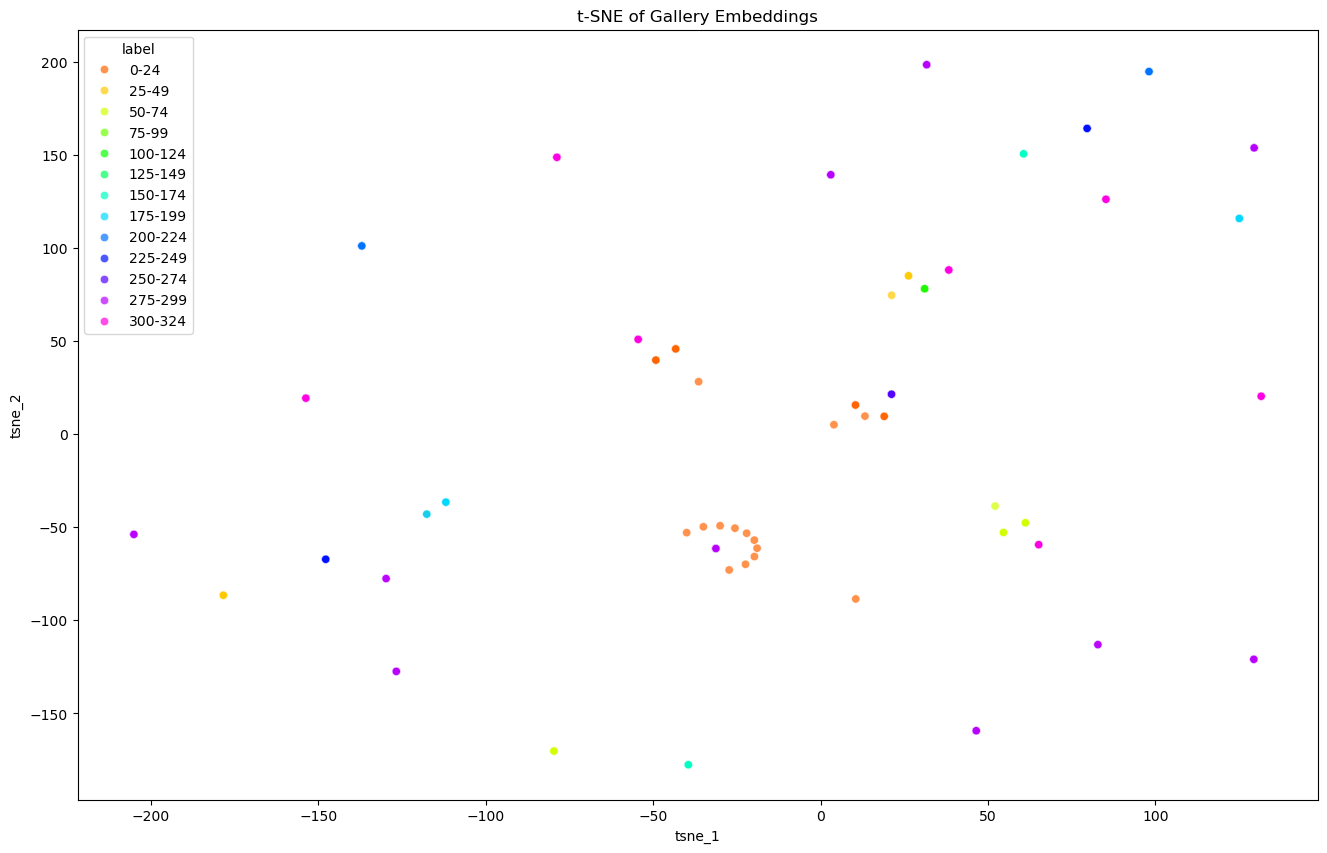

<Figure size 640x480 with 0 Axes>

In [ ]:
r = Retrieval(experiment_code=code)
r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False, aggregate_seeks=True)

In [ ]:
def perfect_correction(hard_predicted_concepts, subject_SEEK, elephant_SEEK):
    return subject_SEEK

def oracle_correction(hard_predicted_concepts, subject_SEEK, elephant_SEEK):
    return elephant_SEEK

complete_loader = DataLoader(dataset, batch_size=64, shuffle=False)

extracted_subject_SEEK_codes, ele_ids_1 = concept_cat.collect_embeddings(complete_loader, MD_finetuned, aggregate_seeks=False, intervention_fn=None)
aggregated_subject_SEEK_codes, ele_ids_2 = concept_cat.collect_embeddings(complete_loader, MD_finetuned, aggregate_seeks=True, intervention_fn=None)
perfect_subject_SEEK_codes, ele_ids_3 = concept_cat.collect_embeddings(complete_loader, MD_finetuned, aggregate_seeks=False, intervention_fn=perfect_correction)
aggregated_perfect_subject_SEEK_codes, ele_ids_4 = concept_cat.collect_embeddings(complete_loader, MD_finetuned, aggregate_seeks=True, intervention_fn=perfect_correction)
ele_SEEK_codes, ele_ids_5 = concept_cat.collect_embeddings(complete_loader, MD_finetuned, aggregate_seeks=False, intervention_fn=oracle_correction)

df = pd.DataFrame({
    'extracted_subject_SEEK_codes': [SEEK(element).__str__() for element in extracted_subject_SEEK_codes],
    'aggregated_subject_SEEK_codes': [SEEK(element).__str__() for element in aggregated_subject_SEEK_codes],
    'perfect_subject_SEEK_codes': [SEEK(element).__str__() for element in perfect_subject_SEEK_codes],
    'aggregated_perfect_subject_SEEK_codes': [SEEK(element).__str__() for element in aggregated_perfect_subject_SEEK_codes],
    'ele_SEEK_codes': [SEEK(element).__str__() for element in ele_SEEK_codes],
    'ele_id_1': ele_ids_1.cpu(),
    'ele_id_2': ele_ids_2.cpu(),
    'ele_id_3': ele_ids_3.cpu(),
    'ele_id_4': ele_ids_4.cpu(),
    'ele_id_5': ele_ids_5.cpu()
})

df.head(100)

collecting concepts from concept head


100%|██████████| 52/52 [00:22<00:00,  2.36it/s]


collecting concepts from concept head


100%|██████████| 52/52 [00:21<00:00,  2.41it/s]


collecting concepts from concept head


...

collecting concepts from concept head


100%|██████████| 52/52 [00:34<00:00,  1.49it/s]


collecting concepts from concept head


100%|██████████| 52/52 [00:22<00:00,  2.36it/s]


,extracted_subject_SEEK_codes,aggregated_subject_SEEK_codes,perfect_subject_SEEK_codes,aggregated_perfect_subject_SEEK_codes,ele_SEEK_codes,ele_id_1,ele_id_2,ele_id_3,ele_id_4,ele_id_5
0,B00T11E0000-0000X0_S00,B00T11E0000-0000X00S00,B00T1_E9080-4550X0_S__,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
1,B00T11E____-0000X_0S00,B00T11E0000-0000X00S00,B00T11E____-4530X_0S00,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
2,B00T11E____-0000X_0S00,B00T11E0000-0000X00S00,B00T11E____-4030X_0S00,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
3,B00T11E____-0000X_0S00,B00T11E0000-0000X00S00,B00T11E____-4530X_0S00,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
4,B00T11E0000-0000X0_S00,B00T11E0000-0000X00S00,B00T__E0000-4540X_0S00,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
5,B00T11E____-0000X_0S00,B00T11E0000-0000X00S00,B00T11E____-0000X_0S00,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
6,B00T11E9000-____X0_S00,B00T11E0000-0000X00S00,B00T1_E8080-____X0_S00,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
7,B00T11E9000-____X0_S00,B00T11E0000-0000X00S00,B00T11E9080-3000X0_S00,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
8,B00T11E____-4000X_0S00,B00T11E0000-0000X00S00,B00T11E____-4530X_0S_0,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0
9,B00T11E____-0000X_0S00,B00T11E0000-0000X00S00,B00T11E____-4030X_0S00,B00T11E8080-4030X00S00,B00T11E8080-4030X_0S00,0.0,0,0.0,0,0.0


In [93]:
r = Retrieval(experiment_code=code)
print('------------retrieval on extracted subject SEEK codes----------------')
r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_tsne = False, show_matches=False, show_plot=False, aggregate_seeks=False, intervention_fn=None)
print('------------retrieval on aggregated extracted subject SEEK codes----------------')
r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_tsne = False, show_matches=False, show_plot=False, aggregate_seeks=True, intervention_fn=None)
print('------------retrieval on perfect subject SEEK codes----------------')
r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_tsne = False, show_matches=False, show_plot=False, aggregate_seeks=False, intervention_fn=perfect_correction)
print('------------retrieval on aggregated perfect subject SEEK codes----------------')
r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_tsne = False, show_matches=False, show_plot=False, aggregate_seeks=True, intervention_fn=perfect_correction)
print('------------retrieval on elephant SEEK codes----------------')
r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_tsne = False, show_matches=False, show_plot=False, aggregate_seeks=False, intervention_fn=oracle_correction)

------------retrieval on extracted subject SEEK codes----------------
evaluating concept head  
collecting concepts from concept head


100%|██████████| 31/31 [00:13<00:00,  2.32it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.41it/s]


Train Recalls:
Recall@1: 0.45%
Recall@5: 2.12%
Recall@10: 3.23%
Recall@20: 6.92%
Recall@100: 26.30%
Test Recalls:
Recall@1: 0.61%
Recall@5: 1.83%
Recall@10: 3.27%
Recall@20: 6.25%
Recall@100: 27.27%
------------retrieval on aggregated extracted subject SEEK codes----------------
evaluating concept head  
collecting concepts from concept head


...

Train Recalls:
Recall@1: 84.45%
Recall@5: 86.07%
Recall@10: 91.07%
Recall@20: 95.81%
Recall@100: 100.00%
Test Recalls:
Recall@1: 12.03%
Recall@5: 14.01%
Recall@10: 19.04%
Recall@20: 22.77%
Recall@100: 42.96%
------------retrieval on elephant SEEK codes----------------
evaluating concept head   with intervention
collecting concepts from concept head


100%|██████████| 31/31 [00:12<00:00,  2.49it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.53it/s]


Train Recalls:
Recall@1: 83.34%
Recall@5: 84.81%
Recall@10: 89.45%
Recall@20: 96.87%
Recall@100: 100.00%
Test Recalls:
Recall@1: 83.09%
Recall@5: 84.84%
Recall@10: 89.19%
Recall@20: 96.57%
Recall@100: 100.00%


## Bon vu que c'est le souk. Je vais essayer d'apprendre les ele_SEEK, puis aggregate. 

In [ ]:
train_loader = DataLoader(train_subset, batch_size=92, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=92, shuffle=False)

In [ ]:
ele_MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
ele_MD_finetuned.unfreeze()

ele_concept = ConceptHeadTunneled(lr = 1e-5, loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = CrossedHeadNN(), reset_weights=True)

ele_concept.train(train_loader, test_loader, backbone = ele_MD_finetuned, num_epochs=50, predict_ele_SEEK = True)
ele_concept.test(test_loader, backbone = ele_MD_finetuned, predict_ele_SEEK = True)



/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 30 epochs, reseting weights, and the backbone parameters are, True  concept head parameters are  True
Epoch 1/30 - Train Loss: 15.8308, Val Loss: 10.2892 - Train Acc: 64.60%, Val Acc: 76.12% - Train whole-code: 0.25%, Val whole-code: 0.36% - Train left ear: 55.17%, Val left ear: 66.46% - Train right ear: 52.73%, Val right ear: 65.02%
Epoch 2/30 - Train Loss: 10.2348, Val Loss: 9.3873 - Train Acc: 76.08%, Val Acc: 76.66% - Train whole-code: 0.74%, Val whole-code: 0.36% - Train left ear: 66.88%, Val left ear: 66.67% - Train right ear: 64.67%, Val right ear: 66.49%
Epoch 3/30 - Train Loss: 9.7162, Val Loss: 9.1868 - Train Acc: 76.36%, Val Acc: 76.75% - Train whole-code: 0.69%, Val whole-code: 0.87% - Train left ear: 66.87%, Val left ear: 66.58% - Train right ear: 65.59%, Val right ear: 66.89%
Epoch 4/30 - Train Loss: 9.5710, Val Loss: 9.1215 - Train Acc: 76.63%, Val Acc: 76.99% - Train whole-code: 0.74%, Val whole-code: 0.51% - Train left ear: 67.05%, Val left ear

(12.77927958170573,
 {'sex': 0.9985507249832153,
  'age': 0.9927536249160767,
  'right_tusk': 0.8789565443992615,
  'left_tusk': 0.9132753809293112,
  'R_tear_1': 0.3827246427536011,
  'R_hole_1': 0.7888405799865723,
  'R_tear_2': 0.593855079015096,
  'R_hole_2': 0.9668985565503438,
  'L_tear_1': 0.3560869574546814,
  'L_hole_1': 0.8388695836067199,
  'L_tear_2': 0.669043489297231,
  'L_hole_2': 0.973913049697876,
  'right_extreme': 0.6330145080884297,
  'left_extreme': 0.5798260986804962,
  'ear_special': 0.9234203060468038,
  'body_special': 0.873913065592448,
  'average': 0.7727463869998853,
  'whole_code': 0.017884058070679505,
  'left_ear': 0.6835478357474009,
  'right_ear': 0.6730666732788085})

In [9]:
def perfect_correction(hard_predicted_concepts, subject_SEEK, elephant_SEEK):
    return subject_SEEK

def oracle_correction(hard_predicted_concepts, subject_SEEK, elephant_SEEK):
    return elephant_SEEK

extracted_ele_SEEK_codes, ele_ids_1 = ele_concept.collect_embeddings(test_loader, ele_MD_finetuned, aggregate_seeks=False, intervention_fn=None)
aggregated_ele_SEEK_codes, ele_ids_2 = ele_concept.collect_embeddings(test_loader, ele_MD_finetuned, aggregate_seeks=True, intervention_fn=None)
perfect_ele_SEEK_codes, ele_ids_5 = ele_concept.collect_embeddings(test_loader, ele_MD_finetuned, aggregate_seeks=False, intervention_fn=oracle_correction)

import pandas as pd
df = pd.DataFrame({
    'extracted_ele_SEEK_codes': [SEEK(element).__str__() for element in extracted_ele_SEEK_codes],
    'aggregated_ele_SEEK_codes': [SEEK(element).__str__() for element in aggregated_ele_SEEK_codes],
    'perfect_ele_SEEK_codes': [SEEK(element).__str__() for element in perfect_ele_SEEK_codes],
    'ele_id_1': ele_ids_1.cpu(),
    'ele_id_2': ele_ids_2.cpu(),
    'ele_id_5': ele_ids_5.cpu()
})


collecting concepts from concept head


100%|██████████| 15/15 [00:08<00:00,  1.72it/s]


collecting concepts from concept head


100%|██████████| 15/15 [00:08<00:00,  1.74it/s]


collecting concepts from concept head


100%|██████████| 15/15 [00:08<00:00,  1.69it/s]


In [10]:
df

,extracted_ele_SEEK_codes,aggregated_ele_SEEK_codes,perfect_ele_SEEK_codes,ele_id_1,ele_id_2,ele_id_5
0,B00T11E8000-4000X_0S00,B00T11E8000-4000X_0S00,B00T11E0000-0000X0_S00,71.0,274,46.0
1,B00T11E9000-3000X__S00,B00T11E8000-3000X_0S00,B00T11E0000-0000X_0S00,12.0,4,121.0
2,B00T11E9000-3000X0_S00,B00T11E9080-4000X_0S00,B00T11E8000-3000X_0S00,88.0,110,175.0
3,B00T11E9000-5000X_0S00,B00T11E9000-3040X0_S00,B00T11E8000-3000X_0S00,25.0,145,71.0
4,B00T11E0000-4000X_0S00,B00T11E8080-4000X_0S00,B00T1_E0000-3440X00S00,124.0,180,290.0
...,...,...,...,...,...,...
1308,B00T_1E8900-4030X_0S00,B00T11E0000-3000X00S00,B00T11E9770-3000X0_S00,164.0,155,182.0
1309,B00T11E8000-4000X0_S00,B00T11E9000-4000X00S00,B00T01E0000-0000X_0S00,140.0,183,17.0
1310,B00T11E0000-3000X__S00,B00T11E0000-3000X00S00,B00T11E9000-5440X0_S00,68.0,10,130.0
1311,B00T11E0000-3000X_0S00,B00T11E9000-3000X__S00,B00T11E8000-3000X_0S00,17.0,197,175.0


In [11]:
r = Retrieval(experiment_code=code)
print('------------retrieval on extracted ele SEEK codes----------------')
r.evaluate_model(ele_concept, ba=ele_MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_tsne = False, show_matches=False, show_plot=False, aggregate_seeks=False, intervention_fn=None)
print('------------retrieval on aggregated extracted ele SEEK codes----------------')
r.evaluate_model(ele_concept, ba=ele_MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_tsne = False, show_matches=False, show_plot=False, aggregate_seeks=True, intervention_fn=None)
print('------------retrieval on perfect elephant SEEK codes----------------')
r.evaluate_model(ele_concept, ba=ele_MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_tsne = False, show_matches=False, show_plot=False, aggregate_seeks=False, intervention_fn=oracle_correction)

------------retrieval on extracted ele SEEK codes----------------
evaluating concept head  
collecting concepts from concept head


100%|██████████| 22/22 [00:14<00:00,  1.54it/s]


collecting concepts from concept head


100%|██████████| 15/15 [00:08<00:00,  1.76it/s]


Train Recalls:
Recall@1: 67.54%
Recall@5: 86.42%
Recall@10: 92.63%
Recall@20: 96.72%
Recall@100: 99.60%
Test Recalls:
Recall@1: 1.98%
Recall@5: 3.81%
Recall@10: 4.87%
Recall@20: 6.32%
Recall@100: 16.83%
------------retrieval on aggregated extracted ele SEEK codes----------------
evaluating concept head  
collecting concepts from concept head


...

Train Recalls:
Recall@1: 79.20%
Recall@5: 93.89%
Recall@10: 97.53%
Recall@20: 99.70%
Recall@100: 100.00%
Test Recalls:
Recall@1: 1.22%
Recall@5: 2.06%
Recall@10: 3.50%
Recall@20: 4.04%
Recall@100: 14.70%
------------retrieval on perfect elephant SEEK codes----------------
evaluating concept head   with intervention
collecting concepts from concept head


100%|██████████| 22/22 [00:13<00:00,  1.64it/s]


collecting concepts from concept head


100%|██████████| 15/15 [00:08<00:00,  1.79it/s]


Train Recalls:
Recall@1: 81.17%
Recall@5: 94.04%
Recall@10: 98.13%
Recall@20: 99.95%
Recall@100: 100.00%
Test Recalls:
Recall@1: 82.48%
Recall@5: 94.97%
Recall@10: 98.48%
Recall@20: 100.00%
Recall@100: 100.00%
